<a href="https://colab.research.google.com/github/najahmariyamk-beep/Student_Result_Prediction/blob/main/Student_Result_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (2).json


{'kaggle (2).json': b'{"username":"najahmariyam","key":"c17f46498e2c8f9bec7e0f6bc5f4c3d6"}'}

In [31]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [32]:
!kaggle datasets download -d h2cco3/student-exam-success-dataset

Dataset URL: https://www.kaggle.com/datasets/h2cco3/student-exam-success-dataset
License(s): apache-2.0
student-exam-success-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [33]:
!unzip student-exam-success-dataset.zip

Archive:  student-exam-success-dataset.zip
replace Student Exam Success Dataset.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
df = pd.read_csv('Student Exam Success Dataset.csv')

In [36]:
df.head()

,student_id,study_hours,attendance,gpa,pass
0,1,5.8,0.83,76,0
1,2,15.8,0.55,63,0
2,3,8.2,0.69,62,0
3,4,17.7,0.64,59,0
4,5,18.8,0.91,65,1


In [37]:
df.shape

(60, 5)

In [38]:
df.columns

Index(['student_id', 'study_hours', 'attendance', 'gpa', 'pass'], dtype='object')

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   student_id   60 non-null     int64  
 1   study_hours  60 non-null     float64
 2   attendance   60 non-null     float64
 3   gpa          60 non-null     int64  
 4   pass         60 non-null     int64  
dtypes: float64(2), int64(3)
memory usage: 2.5 KB


In [40]:
df.isnull().sum()

,0
student_id,0
study_hours,0
attendance,0
gpa,0
pass,0


In [41]:
df.describe()

,student_id,study_hours,attendance,gpa,pass
count,60.000000,60.000000,60.000000,60.000000,60.000000
mean,30.500000,10.116667,0.758333,69.200000,0.550000
std,17.464249,5.923128,0.139723,10.172745,0.501692
min,1.000000,0.500000,0.500000,50.000000,0.000000
25%,15.750000,4.850000,0.657500,60.000000,0.000000
50%,30.500000,9.450000,0.740000,68.000000,1.000000
75%,45.250000,15.350000,0.882500,77.000000,1.000000
max,60.000000,19.900000,0.990000,89.000000,1.000000


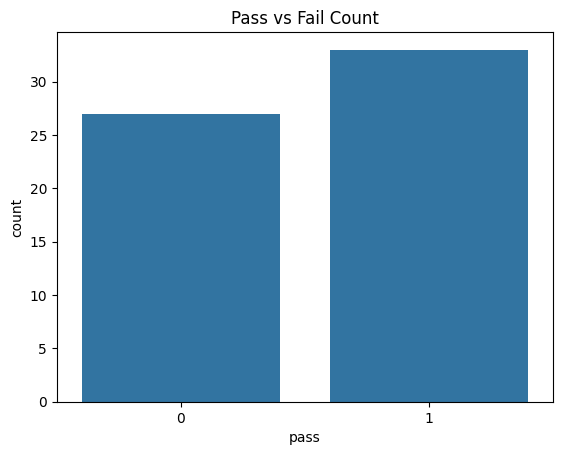

In [42]:
sns.countplot(x='pass', data=df)
plt.title('Pass vs Fail Count')
plt.show()

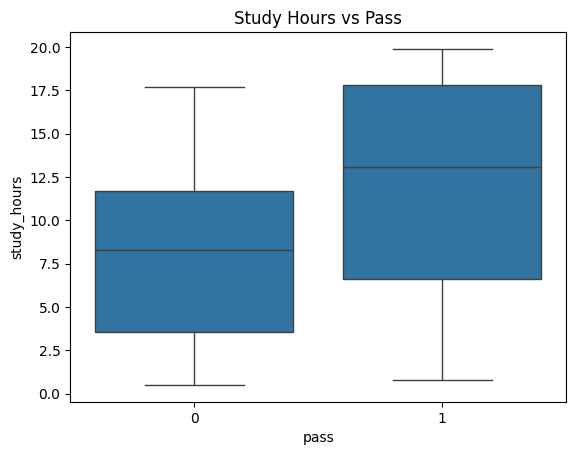

In [43]:
sns.boxplot(x='pass', y='study_hours', data=df)
plt.title('Study Hours vs Pass')
plt.show()

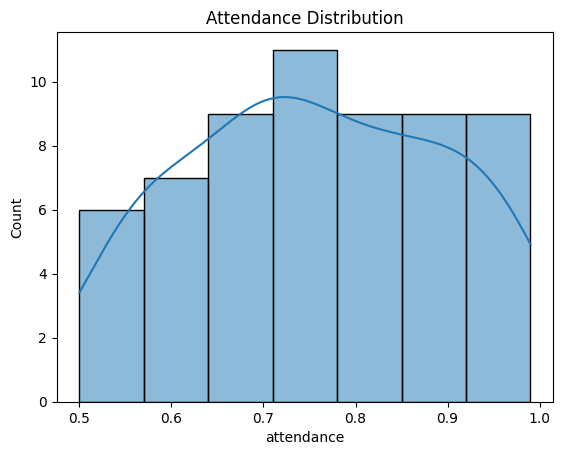

In [44]:
sns.histplot(df['attendance'], kde=True)
plt.title('Attendance Distribution')
plt.show()

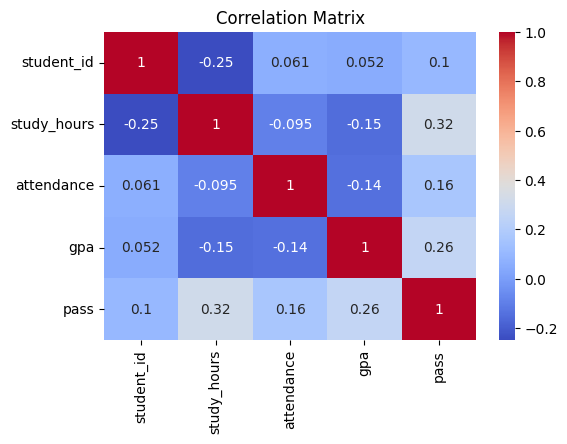

In [45]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [46]:
X = df[['study_hours', 'attendance', 'gpa']]
y = df['pass']

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [48]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [49]:
y_pred = model.predict(X_test)

In [50]:
print(y_pred)

[1 1 1 0 1 1 1 0 1 1 1 0]


In [51]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy)

Accuracy: 0.5


In [52]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[2 5]
 [1 4]]


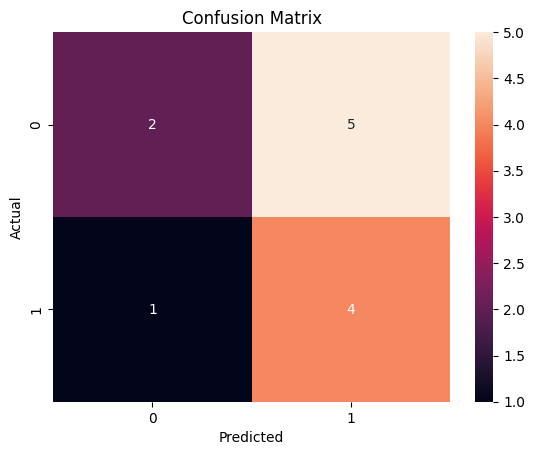

In [53]:
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [54]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.29      0.40         7
           1       0.44      0.80      0.57         5

    accuracy                           0.50        12
   macro avg       0.56      0.54      0.49        12
weighted avg       0.57      0.50      0.47        12



In [55]:
new_student = [[10, 0.85, 78]]

prediction = model.predict(new_student)

print(prediction)

[1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [56]:
import joblib

joblib.dump(model, 'student_result_model.pkl')

['student_result_model.pkl']

In [57]:
loaded_model = joblib.load('student_result_model.pkl')